## Notebook used to generate the numbers of genomic data available in All of Us

This notebook demonstrates where the genomic data are stored within All of Us and how to access them for the brief demonstration of sample size counts

In [ ]:
# pip install hail
# pip install polars

In [7]:
import hail as hl
import os
import subprocess
import json
import re
import polars as pl
import gcsfs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Loading BokehJS ...

In [ ]:
def wb(*args):
    """Run a wb command and return parsed JSON."""
    cmd = ["wb", *args, "--format=json"]
    result = subprocess.check_output(cmd, text=True)
    return json.loads(result)


# Get workspace info
workspace = wb("workspace", "describe")
GOOGLE_CLOUD_PROJECT = workspace["googleProjectId"]

# Get resources
resources = wb("resource", "list")

# WORKSPACE_BUCKET
bucket_resources = [
    r for r in resources
    if r.get("resourceType") == "GCS_BUCKET"
    and "practical_considerations_bucket" in r.get("id", "")
    and "temporary" not in r.get("id", "")
]

if not bucket_resources:
    raise ValueError("No matching bucket found")

WORKSPACE_BUCKET = f"gs://{bucket_resources[0]['bucketName']}"

# WORKSPACE_CDR
bq_resources = [
    r for r in resources
    if r.get("resourceType") in {"BQ_DATASET", "BIGQUERY_DATASET"}
]

cdr_resources = [
    r for r in bq_resources
    if re.match(r"^C\d{4}Q\d+R\d+$", r.get("datasetId", ""))
]

if not cdr_resources:
    raise ValueError("No matching CDR dataset found")

WORKSPACE_CDR = (
    f"{cdr_resources[0]['projectId']}."
    f"{cdr_resources[0]['datasetId']}"
)


In [ ]:
#get variables
version = WORKSPACE_CDR
bucket = WORKSPACE_BUCKET
cohort = "allofus"
google_project_id = GOOGLE_CLOUD_PROJECT

### path to srWGS vds and callsets and counts

In [ ]:
srWGS_snpindel_bucket = 'gs://vwb-aou-datasets-controlled/v9/wgs/short_read/snpindel'
srWGS_acaf_bucket = f'{srWGS_snpindel_bucket}/acaf_threshold/splitMT/hail.mt'
srWGS_exome_bucket = f'{srWGS_snpindel_bucket}/exome/splitMT/hail.mt'
srWGS_clinvar_bucket = f'{srWGS_snpindel_bucket}/clinvar/splitMT/hail.mt'
vds_srwgs_bucket_path = f'{srWGS_snpindel_bucket}/vds/hail.vds'

In [ ]:
#initialize (only run once)
hl.init(
    gcs_requester_pays_configuration=google_project_id
)

In [ ]:
hl.default_reference(new_default_reference = "GRCh38")

In [ ]:
# vds counts
vds = hl.vds.read_vds(vds_srwgs_bucket_path)
n_variants, n_samples = vds.variant_data.count()
print(f"srWGS VDS: {n_variants:,} variants across {n_samples:,} samples")

# acaf callset counts
acaf_mt = hl.read_matrix_table(srWGS_acaf_bucket)
n_variants, n_samples = acaf_mt.count()
print(f"ACAF callset: {n_variants:,} variants across {n_samples:,} samples")

# exome callset counts
exome_mt = hl.read_matrix_table(srWGS_exome_bucket)
n_variants, n_samples = exome_mt.count()
print(f"Exome callset: {n_variants:,} variants across {n_samples:,} samples")

#clinvar callset counts
clinvar_mt = hl.read_matrix_table(srWGS_clinvar_bucket)
n_variants, n_samples = clinvar_mt.count()
print(f"ClinVar callset: {n_variants:,} variants across {n_samples:,} samples")

### path to sv data and counts

In [ ]:
sv_bucket = 'gs://vwb-aou-datasets-controlled/v9/wgs/short_read/structural_variants/vcf/sites-only/AoU_srWGS_SV.v9.sites_only.vcf.gz'

In [ ]:
mt = hl.import_vcf(sv_bucket, force_bgz=True, reference_genome='GRCh38')

In [ ]:
# Total SV sites
n_sites = mt.count_rows()
print(f"Total SV sites: {n_sites}")

In [ ]:
# Total calls across all samples (sum of AC)
mt = mt.annotate_rows(ac = mt.info.AC[0])
total_calls = mt.aggregate_rows(hl.agg.sum(mt.ac))
print(f"Total SV calls across all samples: {total_calls}")

In [ ]:
# AN can vary per site (some samples may be missing),
# so take the max AN across all sites as the most reliable sample count
max_an = mt.aggregate_rows(hl.agg.max(mt.info.AN))
n_samples = max_an // 2
print(f"Number of samples: {n_samples}")

### path to lrWGS data and person counts

In [ ]:
fs = gcsfs.GCSFileSystem(requester_pays=True)

with fs.open('gs://vwb-aou-datasets-controlled/v9/wgs/long_read/manifest.tsv') as f:
    manifest = pl.read_csv(f, separator='\t')

print(f"Number of individuals with long-read WGS data: {manifest.n_unique('research_id'):,}")

### determine ancestry counts in srWGS data

In [4]:
fs = gcsfs.GCSFileSystem(requester_pays=True)
with fs.open('gs://vwb-aou-datasets-controlled/v9/wgs/short_read/snpindel/aux/ancestry/ancestry_preds.tsv') as f:
    ancestry_pred = pl.read_csv(f, separator='\t')

In [6]:
for col in ['ancestry_pred', 'ancestry_pred_other']:
    print(f"\n{col}:")
    print(
        ancestry_pred[col]
        .value_counts(sort=True)
        .with_columns((pl.col('count') / pl.col('count').sum() * 100).round(2).alias('percent'))
    )


ancestry_pred:
shape: (6, 3)
┌───────────────┬────────┬─────────┐
│ ancestry_pred ┆ count  ┆ percent │
│ ---           ┆ ---    ┆ ---     │
│ str           ┆ u32    ┆ f64     │
╞═══════════════╪════════╪═════════╡
│ eur           ┆ 302714 ┆ 56.51   │
│ amr           ┆ 107928 ┆ 20.15   │
│ afr           ┆ 100800 ┆ 18.82   │
│ eas           ┆ 15893  ┆ 2.97    │
│ sas           ┆ 6176   ┆ 1.15    │
│ mid           ┆ 2151   ┆ 0.4     │
└───────────────┴────────┴─────────┘

ancestry_pred_other:
shape: (7, 3)
┌─────────────────────┬────────┬─────────┐
│ ancestry_pred_other ┆ count  ┆ percent │
│ ---                 ┆ ---    ┆ ---     │
│ str                 ┆ u32    ┆ f64     │
╞═════════════════════╪════════╪═════════╡
│ eur                 ┆ 284004 ┆ 53.02   │
│ amr                 ┆ 97261  ┆ 18.16   │
│ afr                 ┆ 94465  ┆ 17.64   │
│ oth                 ┆ 40029  ┆ 7.47    │
│ eas                 ┆ 12980  ┆ 2.42    │
│ sas                 ┆ 5631   ┆ 1.05    │
│ mid            

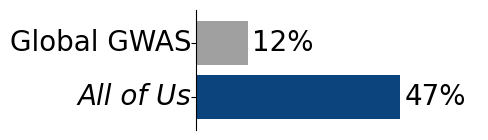

In [18]:
# Calculate % non-EUR from ancestry_pred_other
non_eur_pct = (ancestry_pred['ancestry_pred_other'] != 'eur').mean() * 100

labels = ['Global GWAS', 'All of Us']
#12% obtained from https://gwasdiversitymonitor.com/ accessed on July 1, 2026
global_noneur_pct = 12
values = [global_noneur_pct, non_eur_pct]

fig, ax = plt.subplots(figsize=(5, 1.5))

colors = ['#0C447D', '#a0a0a0']
for i, (label, val) in enumerate(zip(['All of Us', 'Global GWAS'], [non_eur_pct, global_noneur_pct])):
    ax.barh(i, val, color=colors[i], height=0.8)
    ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=20)

ax.set_yticks([0, 1])
ax.set_yticklabels([])
ax.text(-1, 0, 'All of Us', fontsize=20, fontstyle='italic', ha='right', va='center')
ax.text(-1, 1, 'Global GWAS', fontsize=20, ha='right', va='center')

ax.set_xlim(0, 65)
ax.set_ylim(-0.6, 1.6)
ax.set_xticks([])
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
##save figure and table to bucket
for ext in ["pdf", "png"]:
    fig.savefig(f"/home/jupyter/workspace/practical_considerations_bucket/data/fig_aou_v9_genetic_ancestry.{ext}", dpi=300, bbox_inches="tight")
    #change "jupyter" to "dataproc" if in a dataproc workspace for other analyses